# CAP4453 — Assignment 3: Transfer Learning (ResNet-18 → CIFAR-10)

**What you will do:** Use an ImageNet-pretrained **ResNet-18** and perform **last-layers fine-tuning** on CIFAR-10 by **freezing the backbone** and training **only the classifier head**.

**Rules for this assignment**
- Select the **best checkpoint using validation accuracy**.
- Run **test evaluation once** using the best validation checkpoint.

You will report:
- Best **validation accuracy**
- Final **test accuracy**
- Training curves: **train/val loss** and **train/val accuracy**
- A small set of **misclassified examples** (with predicted + true labels)


## 0) Setup

In [108]:
# ====== Imports (provided) ======
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

import matplotlib.pyplot as plt

# (Optional) If you want nicer progress bars:
from tqdm.auto import tqdm


In [109]:
# ====== Reproducibility + device (provided) ======
SEED = 4453
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [110]:
# ====== Fixed training configuration (do NOT tune) ======
NUM_CLASSES = 10
INPUT_SIZE = 224

# Keep this CPU-friendly:
BATCH_SIZE = 512 if torch.cuda.is_available() else 32
EPOCHS = 30 if torch.cuda.is_available() else 5

LR = 1e-3
WEIGHT_DECAY = 1e-3

NUM_WORKERS = 8  # set to 0 if you have DataLoader issues on your machine
PIN_MEMORY = torch.cuda.is_available()

print(dict(BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS, LR=LR, WEIGHT_DECAY=WEIGHT_DECAY, INPUT_SIZE=INPUT_SIZE))


{'BATCH_SIZE': 512, 'EPOCHS': 30, 'LR': 0.001, 'WEIGHT_DECAY': 0.001, 'INPUT_SIZE': 224}


## 1) Data transforms

Create:
- `train_transform`: resize to `INPUT_SIZE`, apply **light augmentation**, then ImageNet normalization
- `eval_transform`: resize to `INPUT_SIZE`, **no random ops**, then ImageNet normalization

**Hint:** `ResNet18_Weights.IMAGENET1K_V1.meta["mean"]` and `["std"]` provide ImageNet mean/std.


In [111]:
# ====== STUDENT TODO: define transforms ======
weights = ResNet18_Weights.IMAGENET1K_V1
# The weights.meta["mean"] and ["std"] keys might be missing in some torchvision versions.
# Manually define ImageNet mean and std for robustness.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# STUDENT TODO:
train_transform = transforms.Compose ([
transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
transforms.RandomHorizontalFlip(),
transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
transforms.RandomRotation(5),
transforms.ToTensor(),
transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose ([
transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
transforms.ToTensor(),
transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Quick sanity check (leave this as-is):
print("train_transform:", train_transform)
print("eval_transform:", eval_transform)


train_transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=None)
    RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
eval_transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 2) Dataset and train/val split

Load CIFAR-10 and create a **train/validation split** from the official training set.

**Important:** Validation must be **deterministic** (no random augmentation).  
A simple approach is to:
1. Load the CIFAR-10 train set twice (once with `train_transform`, once with `eval_transform`).
2. Use the **same index split** for both.


In [112]:
# ====== STUDENT TODO: load datasets and split indices ======
DATA_ROOT = "./data"

# STUDENT TODO:
# - Create two CIFAR-10 train datasets:
#   train_full_aug uses train_transform
#   train_full_eval uses eval_transform
# - Create the CIFAR-10 test dataset using eval_transform

train_full_aug = datasets.CIFAR10(root=DATA_ROOT, train=True,  download=True, transform=train_transform)   # TODO
train_full_eval = datasets.CIFAR10(root=DATA_ROOT, train=True,  download=True, transform=eval_transform)  # TODO
test_dataset = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=eval_transform)     # TODO

# STUDENT TODO:
# Create a deterministic split: e.g., 45k train / 5k val
num_total = len(train_full_aug)  # TODO: len(train_full_aug)
num_val = 5_000 # TODO
num_train = num_total - num_val  # TODO

# Create indices with a fixed seed
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(num_total, generator=g).tolist()  # TODO: torch.randperm(num_total, generator=g).tolist()
train_idx = perm[:num_train]  # TODO
val_idx = perm[num_train:]   # TODO

# Build subsets:
train_dataset = Subset(train_full_aug,  train_idx)  # TODO: Subset(train_full_aug, train_idx)
val_dataset = Subset(train_full_eval, val_idx)    # TODO: Subset(train_full_eval, val_idx)

print("train/val/test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))


train/val/test sizes: 45000 5000 10000


## 3) DataLoaders

Create `train_loader`, `val_loader`, and `test_loader`.

- Use `shuffle=True` for training only.
- Use `shuffle=False` for validation and test.


In [113]:
# ====== STUDENT TODO: build dataloaders ======
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)  # TODO
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)    # TODO
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)   # TODO

# Suggested pattern (edit as needed):
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
# val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
# test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Loaders ready.")


Loaders ready.


## 4) Model: ResNet-18 (freeze backbone, train head)

Implement `build_resnet18_head_only()`:

1. Load ImageNet-pretrained ResNet-18  
2. Replace final `fc` layer to output 10 classes  
3. Freeze **all backbone parameters**  
4. Ensure only the classifier head parameters are trainable


In [114]:
from torchvision.models import resnet18, ResNet18_Weights

# ====== STUDENT TODO: build model (head-only fine-tuning) ======
def build_resnet18_head_only(num_classes: int):
    """Return an ImageNet-pretrained ResNet-18 with a new classifier head.

    Requirements:
    - Use pretrained ImageNet weights
    - Replace final fc layer -> num_classes outputs
    - Freeze backbone (everything except the new fc)
    """
    # ✅ provided: load pretrained resnet18 (ImageNet)
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)

    # TODO: replace final layer
    in_features = model.fc.in_features

    model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
    )

    # TODO: freeze backbone parameters (everything except model.fc)
    for name, p in model.named_parameters():
      if not (name.startswith("fc.") or name.startswith("layer4.")):
        p.requires_grad = False

    return model

model = build_resnet18_head_only(NUM_CLASSES).to(device)

# Sanity check: print trainable parameter names and count
trainable = [(n, p.numel()) for n, p in model.named_parameters() if p.requires_grad]
print("Trainable tensors:", [n for n, _ in trainable])
print("Trainable params:", sum(x for _, x in trainable))


Trainable tensors: ['layer4.0.conv1.weight', 'layer4.0.bn1.weight', 'layer4.0.bn1.bias', 'layer4.0.conv2.weight', 'layer4.0.bn2.weight', 'layer4.0.bn2.bias', 'layer4.0.downsample.0.weight', 'layer4.0.downsample.1.weight', 'layer4.0.downsample.1.bias', 'layer4.1.conv1.weight', 'layer4.1.bn1.weight', 'layer4.1.bn1.bias', 'layer4.1.conv2.weight', 'layer4.1.bn2.weight', 'layer4.1.bn2.bias', 'fc.0.weight', 'fc.0.bias', 'fc.3.weight', 'fc.3.bias']
Trainable params: 8527626


## 5) Loss and optimizer (fixed settings)

Use:
- Cross-entropy loss
- Adam optimizer
- Optimize **only** trainable parameters (`requires_grad=True`)


In [115]:
# ====== STUDENT TODO: define criterion and optimizer ======
criterion = nn.CrossEntropyLoss()  # TODO:

# Collect only trainable parameters
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": LR * 0.01},
    {"params": model.fc.parameters(),     "lr": LR},
], weight_decay=WEIGHT_DECAY)  # TODO:

print("Optimizer ready. Trainable param tensors:", len(trainable_params))


Optimizer ready. Trainable param tensors: 19


## 6) Training and evaluation utilities

Implement:
- `compute_accuracy(logits, targets)`
- `train_one_epoch(...)` → returns `(avg_loss, avg_acc)`
- `evaluate(...)` → returns `(avg_loss, avg_acc)` (with `torch.no_grad()`)

**Tip:** Accuracy = correct / total, where `pred = logits.argmax(dim=1)`.


In [116]:
# ====== STUDENT TODO: training utilities ======
def compute_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Return accuracy for a batch."""
    # TODO
    preds = logits.argmax(dim=1)              # predicted class index per sample
    correct = (preds == targets).sum().item() # number of correct predictions
    return correct / targets.size(0)          # fraction correct

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Return (avg_loss, avg_acc)."""
    model.train()

    running_loss    = 0.0
    running_correct = 0
    total_samples   = 0


    # TODO: initialize running sums
    # TODO: loop over loader:
    #   - move data to device
    #   - forward
    #   - loss
    #   - backward + optimizer.step
    #   - accumulate loss and correct predictions

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)

        # Backward pass + parameter update
        loss.backward()
        optimizer.step()

        # Accumulate statistics
        batch_size       = labels.size(0)
        running_loss    += loss.item() * batch_size
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples   += batch_size

    avg_loss = running_loss / total_samples
    avg_acc  = running_correct / total_samples
    return avg_loss, avg_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate. Return (avg_loss, avg_acc)."""
    model.eval()

    # TODO: similar to train but no backward
    running_loss    = 0.0
    running_correct = 0
    total_samples   = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss   = criterion(logits, labels)

        batch_size       = labels.size(0)
        running_loss    += loss.item() * batch_size
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples   += batch_size

    avg_loss = running_loss    / total_samples
    avg_acc  = running_correct / total_samples
    return avg_loss, avg_acc

## 7) Single-run training loop + best checkpoint by validation accuracy

Run training for `EPOCHS` (one run only).  
After each epoch:
- compute train loss/acc
- compute val loss/acc
- update curves
- **save checkpoint** if validation accuracy improves

Save path: `best_resnet18_head_cifar10.pt`


In [117]:
# ====== STUDENT TODO: training loop + checkpointing ======
BEST_CKPT_PATH = "best_resnet18_head_cifar10.pt"

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = -1.0
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    # TODO: call train_one_epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # TODO: call evaluate on val
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # TODO: append to history lists

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # TODO: if val_acc improves, save checkpoint:
    # torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_acc": val_acc}, BEST_CKPT_PATH)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        torch.save(
            {"model_state": model.state_dict(), "epoch": epoch, "val_acc": val_acc},
            BEST_CKPT_PATH,
        )

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val loss={val_loss:.4f} acc={val_acc:.4f}")

print("Best epoch:", best_epoch, "Best val acc:", best_val_acc)
print("Saved best checkpoint to:", BEST_CKPT_PATH)


Epoch 01/30 | train loss=0.9498 acc=0.6816 | val loss=0.4648 acc=0.8424
Epoch 02/30 | train loss=0.5029 acc=0.8250 | val loss=0.3755 acc=0.8720
Epoch 03/30 | train loss=0.4268 acc=0.8520 | val loss=0.3420 acc=0.8864
Epoch 04/30 | train loss=0.3847 acc=0.8674 | val loss=0.3096 acc=0.8954
Epoch 05/30 | train loss=0.3529 acc=0.8787 | val loss=0.2906 acc=0.9024
Epoch 06/30 | train loss=0.3272 acc=0.8867 | val loss=0.2864 acc=0.9066
Epoch 07/30 | train loss=0.3107 acc=0.8936 | val loss=0.2765 acc=0.9080
Epoch 08/30 | train loss=0.2969 acc=0.8978 | val loss=0.2681 acc=0.9090
Epoch 09/30 | train loss=0.2763 acc=0.9035 | val loss=0.2582 acc=0.9126
Epoch 10/30 | train loss=0.2623 acc=0.9080 | val loss=0.2573 acc=0.9148
Epoch 11/30 | train loss=0.2549 acc=0.9125 | val loss=0.2511 acc=0.9160
Epoch 12/30 | train loss=0.2418 acc=0.9149 | val loss=0.2466 acc=0.9178
Epoch 13/30 | train loss=0.2351 acc=0.9177 | val loss=0.2435 acc=0.9210
Epoch 14/30 | train loss=0.2272 acc=0.9215 | val loss=0.2382 acc

## 8) Plot learning curves

Create:
- Loss curves: train vs val
- Accuracy curves: train vs val


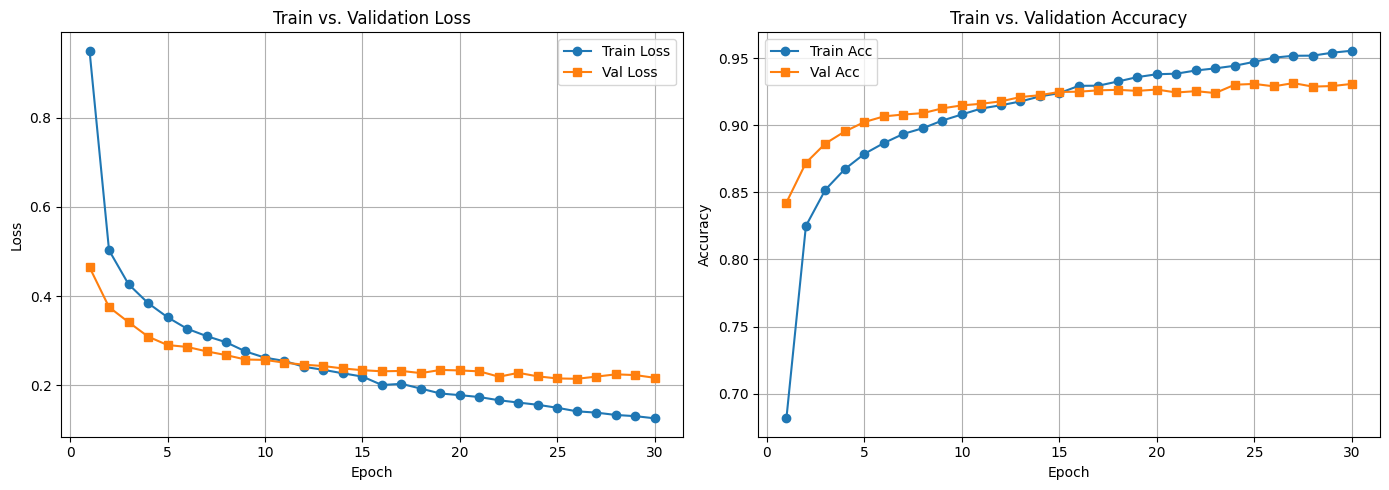

Learning curves saved to learning_curves.png


In [118]:
# ====== STUDENT TODO: plot curves ======
# Use history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"]
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: plot loss
ax = axes[0]
ax.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
ax.plot(epochs_range, history["val_loss"],   marker="s", label="Val Loss")
ax.set_title("Train vs. Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)

# TODO: plot accuracy
ax = axes[1]
ax.plot(epochs_range, history["train_acc"], marker="o", label="Train Acc")
ax.plot(epochs_range, history["val_acc"],   marker="s", label="Val Acc")
ax.set_title("Train vs. Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()
print("Learning curves saved to learning_curves.png")

## 9) Load best checkpoint and evaluate on validation and test

1. Load `BEST_CKPT_PATH`  
2. Evaluate **validation** and **test**  
3. Report: best val accuracy and final test accuracy


In [119]:
# ====== STUDENT TODO: load checkpoint and evaluate ======
ckpt = torch.load(BEST_CKPT_PATH, map_location=device)
# TODO:
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val_acc={ckpt['val_acc']:.4f})")
# TODO: compute final val metrics
final_val_loss, final_val_acc = evaluate(model, val_loader, criterion, device)

# TODO: compute final test metrics (run once)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Final validation accuracy: {final_val_acc:.4f}  (loss={final_val_loss:.4f})")
print(f"Final test accuracy:       {test_acc:.4f}  (loss={test_loss:.4f})")

Loaded best checkpoint from epoch 27 (val_acc=0.9314)
Final validation accuracy: 0.9314  (loss=0.2199)
Final test accuracy:       0.9178  (loss=0.2601)


## 10) Misclassified examples

Show a small set of misclassified **test** images:
- image
- predicted label
- true label

**Tip:** CIFAR-10 class names are in `test_dataset.classes`.


Collected 20 misclassified examples. Displaying 5.


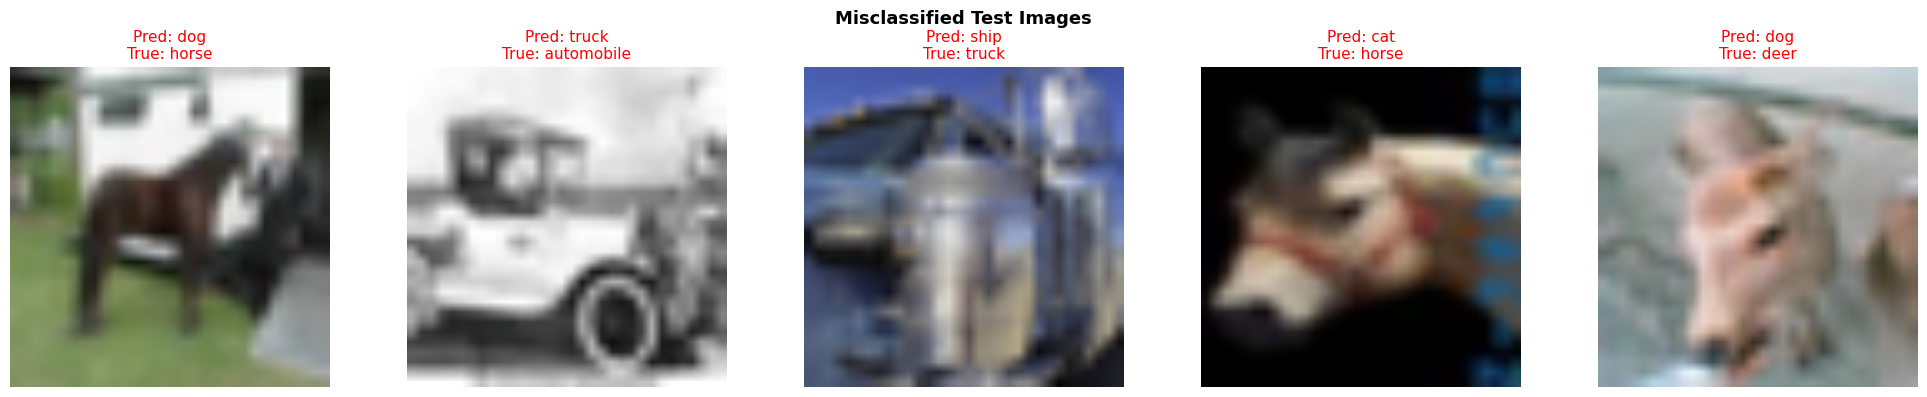

Misclassified examples saved to misclassified_examples.png


In [120]:
# ====== STUDENT TODO: show misclassified examples ======
# Goal: collect a few misclassified test samples and visualize them.

CLASSES = test_dataset.classes  # list of 10 class name strings
MEAN = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
STD  = torch.tensor(IMAGENET_STD ).view(3, 1, 1)

def unnormalize(tensor):
    """Reverse ImageNet normalisation so pixel values are in [0, 1]."""
    return (tensor * STD + MEAN).clamp(0.0, 1.0)

# Hints:
# - model.eval()
# - loop over test_loader
# - preds = logits.argmax(dim=1)
# - find where preds != y
# - store (image_tensor, pred, true)
# - visualize with matplotlib (remember to unnormalize if you want correct colors)

misclassified = []  # TODO: fill with tuples (img, pred_idx, true_idx)
MAX_COLLECT   = 20   # gather up to 20 so we can pick 5 to display

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        preds  = logits.argmax(dim=1)

        # Identify misclassified indices within this batch
        wrong_mask = preds != labels
        for img, pred, true in zip(
            images[wrong_mask].cpu(),
            preds[wrong_mask].cpu().tolist(),
            labels[wrong_mask].cpu().tolist(),
        ):
            misclassified.append((img, pred, true))
            if len(misclassified) >= MAX_COLLECT:
                break

        if len(misclassified) >= MAX_COLLECT:
            break

print(f"Collected {len(misclassified)} misclassified examples. Displaying 5.")

# TODO: visualize at least 5
num_show = min(5, len(misclassified))
fig, axes = plt.subplots(1, num_show, figsize=(4 * num_show, 4))

if num_show == 1:
    axes = [axes]  # make iterable when there is only one panel

for ax, (img, pred_idx, true_idx) in zip(axes, misclassified[:num_show]):
    # Convert normalised tensor -> displayable numpy array (H x W x C)
    img_display = unnormalize(img).permute(1, 2, 0).numpy()
    ax.imshow(img_display)
    ax.axis("off")
    ax.set_title(
        f"Pred: {CLASSES[pred_idx]}\nTrue: {CLASSES[true_idx]}",
        fontsize=11,
        color="red",
    )

plt.suptitle("Misclassified Test Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("misclassified_examples.png", dpi=150)
plt.show()
print("Misclassified examples saved to misclassified_examples.png")


## Submission checklist

Before you submit:
- [ ] Your code trains **only the classifier head** (backbone frozen)
- [ ] You trained and selected the best checkpoint by **validation accuracy**
- [ ] You reported:
  - training and validation curves for loss values and accuracy
  - best validation accuracy
  - final test accuracy (best checkpoint, evaluated once)
- [ ] You included:
  - train/val loss curve
  - train/val accuracy curve
  - ≥ 5 misclassified examples with predicted + true labels
